In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import rasterio
import cv2
from skimage.filters import threshold_otsu

In [14]:
def load_sar_tiff(path):
    with rasterio.open(path) as src:
        vv = src.read(1).astype(np.float32)
        vh = src.read(2).astype(np.float32)

    # Clip
    vv = np.clip(vv, -35, 5)
    vh = np.clip(vh, -40, 0)

    # Normalize
    vv = (vv + 35) / 40
    vh = (vh + 40) / 40

    # Stack
    img = np.stack([vv, vh], axis=-1)

    # Resize
    img = tf.image.resize(img, (512,512)).numpy()

    return img

In [16]:
def load_mask(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.float32)

    mask = tf.image.resize(mask[..., np.newaxis], (512,512)).numpy()
    mask = (mask > 0.5).astype(np.uint8)

    return mask.squeeze()

In [44]:
def otsu_segmentation(image):
    vv = image[:, :, 0]
    vh = image[:, :, 1]

    fused = 0.3 * vv + 0.7 * vh
    fused_8bit = (fused * 255).astype(np.uint8)

    _, otsu_mask = cv2.threshold(
        fused_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    otsu_mask = otsu_mask // 255 

    otsu_mask = 1 - otsu_mask

    return otsu_mask

In [50]:
def unet_segmentation(model, image):
    pred = model.predict(np.expand_dims(image, axis=0))[0]

    pred_mask = (pred > 0.4).astype(np.uint8)

    return pred_mask.squeeze()

In [43]:
def compute_metrics(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    iou = intersection / (union + 1e-6)

    accuracy = (y_true == y_pred).sum() / y_true.size

    return iou, accuracy

In [39]:
def compare_results_multiple(samples, save_path="comparison_clean.png"):
    rows = len(samples)
    cols = 4

    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))

    col_titles = ["Image", "Ground Truth", "Otsu", "U-Net"]

    for row_idx, (image, gt_mask, otsu_mask, unet_mask) in enumerate(samples):

        # Fused image
        vv = image[:, :, 0]
        vh = image[:, :, 1]
        fused = 0.3 * vv + 0.7 * vh
        fused = (fused - fused.min()) / (fused.max() - fused.min() + 1e-6)

        images = [fused, gt_mask, otsu_mask, unet_mask]

        # Metrics
        iou_o, acc_o = compute_metrics(gt_mask, otsu_mask)
        iou_u, acc_u = compute_metrics(gt_mask, unet_mask)

        for col_idx in range(cols):
            ax = axes[row_idx, col_idx] if rows > 1 else axes[col_idx]
            ax.imshow(images[col_idx], cmap='gray')
            ax.axis("off")

            # Column titles only on first row
            if row_idx == 0:
                ax.set_title(col_titles[col_idx], fontsize=14, weight='bold')

            # Row labels
            if col_idx == 0:
                ax.set_ylabel(f"Sample {row_idx+1}", fontsize=12, weight='bold')

            # Metrics (clean box)
            if col_idx == 2:
                ax.text(
                    0.03, 0.03,
                    f"IoU: {iou_o:.3f}\nAcc: {acc_o:.3f}",
                    transform=ax.transAxes,
                    fontsize=10,
                    color='white',
                    bbox=dict(facecolor='black', alpha=0.7, pad=3)
                )

            elif col_idx == 3:
                ax.text(
                    0.03, 0.03,
                    f"IoU: {iou_u:.3f}\nAcc: {acc_u:.3f}",
                    transform=ax.transAxes,
                    fontsize=10,
                    color='white',
                    bbox=dict(facecolor='black', alpha=0.7, pad=3)
                )

    plt.tight_layout()

    # Save high-quality figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved at: {save_path}")

In [23]:
import tensorflow as tf

model = tf.keras.models.load_model("./unet_epoch_049.h5", compile=False)

In [51]:
samples = [
    ("../Working/Images/Oil/Images/00001.tif", "../Working/Images/Oil/Mask/00001_segmentation.tif"),
    ("../Working/Images/Oil/Images/00002.tif", "../Working/Images/Oil/Mask/00002_segmentation.tif"),
    ("../Working/Images/Oil/Images/00003.tif", "../Working/Images/Oil/Mask/00003_segmentation.tif"),
]
samples_data = []

for img_path, mask_path in samples:
    image = load_sar_tiff(img_path)
    gt_mask = load_mask(mask_path)

    otsu_mask = otsu_segmentation(image)
    unet_mask = unet_segmentation(model, image)

    samples_data.append((image, gt_mask, otsu_mask, unet_mask))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


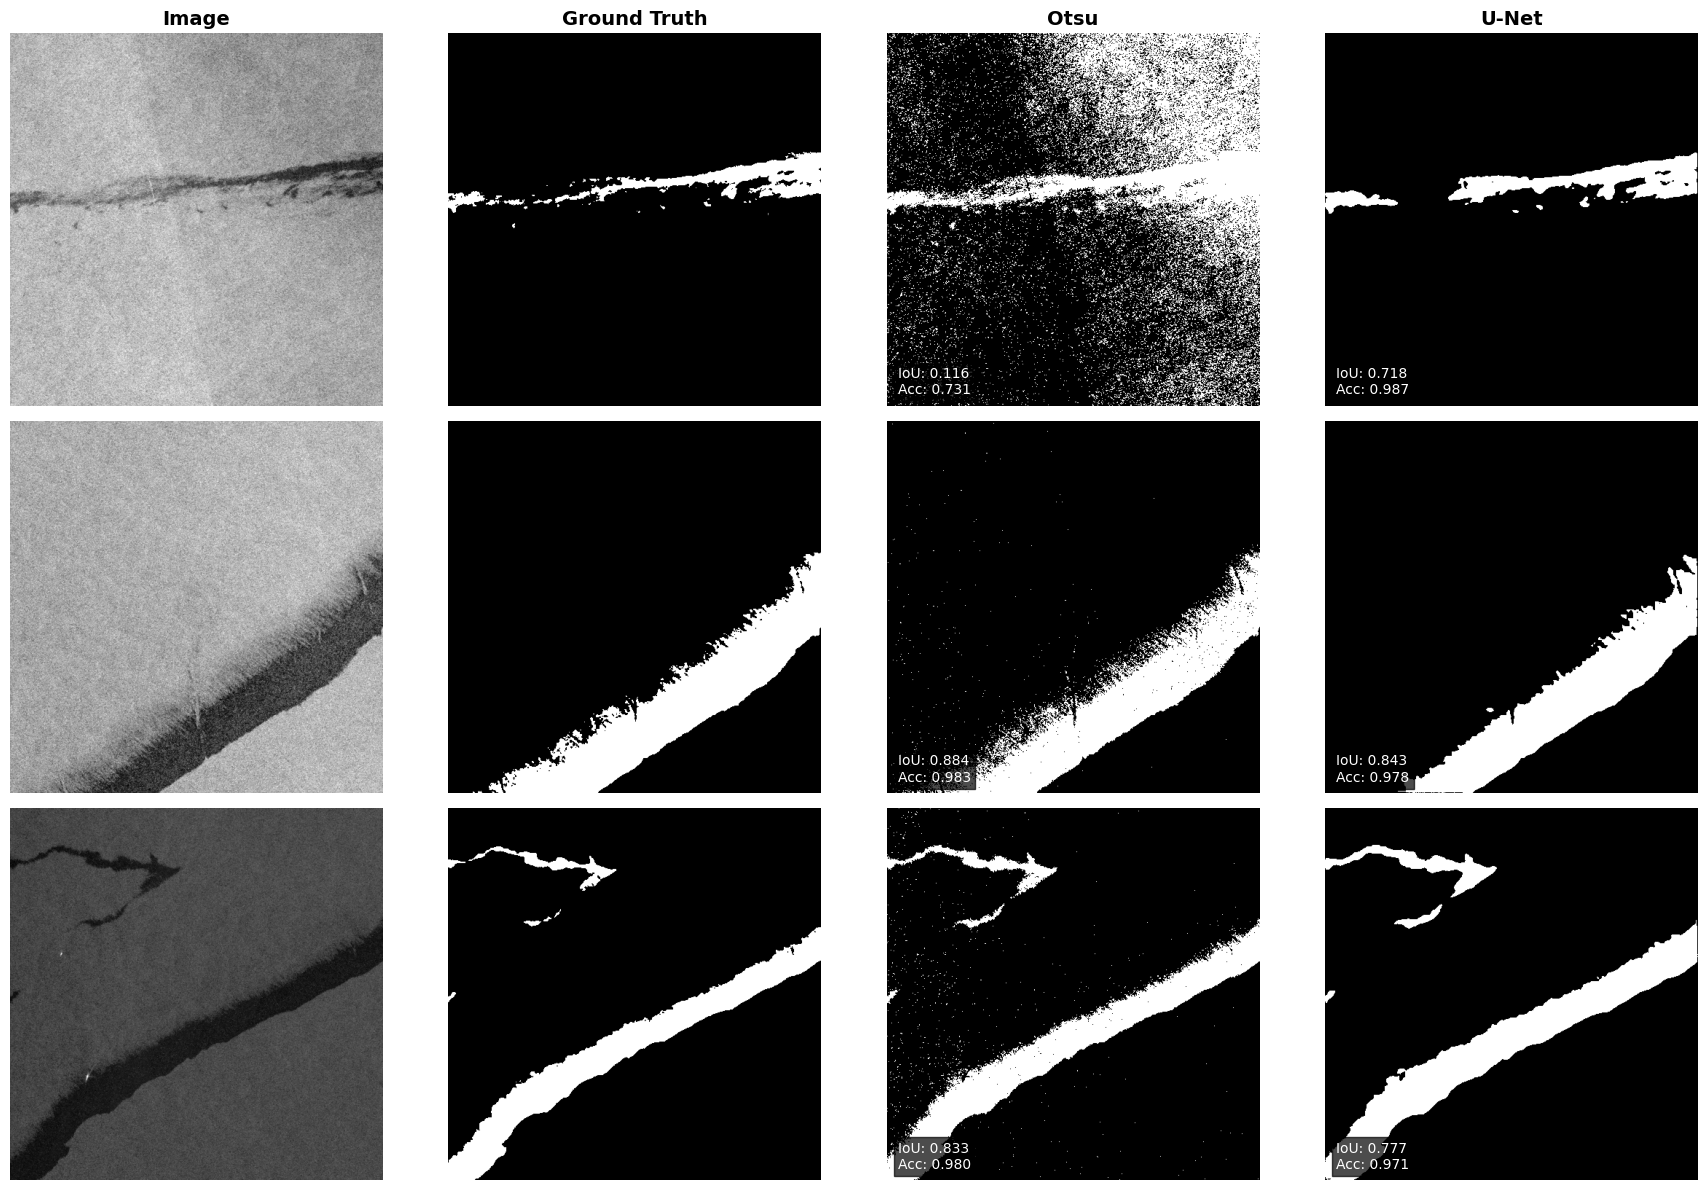

Saved at: final_comparison.png


In [52]:
compare_results_multiple(samples_data, "final_comparison.png")